<a href="https://colab.research.google.com/github/Gangamma-yn/Gangamma-yn/blob/main/day09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install diffusers transformers accelerate torch pillow

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Saving cat.png to cat.png
Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

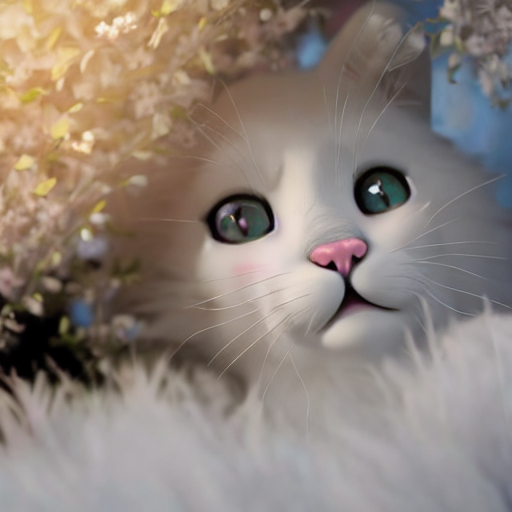

Image generated successfully!
Saved as: generated_cat.png


In [ ]:
# Install required libraries
!pip install diffusers transformers accelerate torch pillow -q

# Import libraries
from diffusers import StableDiffusionImg2ImgPipeline
from PIL import Image
from IPython.display import display
from google.colab import files
import torch
import os

# Upload image
uploaded = files.upload()

# Get uploaded filename
image_path = list(uploaded.keys())[0]

# Select device
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# Load Stable Diffusion Image-to-Image model
pipe = StableDiffusionImg2ImgPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16 if device == "cuda" else torch.float32
)

# Move model to GPU
pipe = pipe.to(device)

# Load input image
init_image = Image.open("/content/cat.png").convert("RGB")

# Resize image
init_image = init_image.resize((512, 512))

# Prompt
prompt = """
A cute fluffy white cat sitting in a magical garden,
highly detailed,
realistic,
cinematic lighting,
4k quality
"""

# Generate new image
result = pipe(
    prompt=prompt,
    image=init_image,
    strength=0.6,
    guidance_scale=7.5
)

# Get generated image
generated_image = result.images[0]

# Save output image
generated_image.save("generated_cat.png")

# Display generated image
display(generated_image)

print("Image generated successfully!")
print("Saved as: generated_cat.png")

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 481kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.82MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.2MB/s]


Epoch [1/20] D Loss: 0.1289 G Loss: 7.7216
Epoch [2/20] D Loss: 0.8523 G Loss: 3.4308
Epoch [3/20] D Loss: 1.4330 G Loss: 1.8130
Epoch [4/20] D Loss: 0.0711 G Loss: 6.6360
Epoch [5/20] D Loss: 0.7383 G Loss: 3.7959
Epoch [6/20] D Loss: 0.3507 G Loss: 7.0519
Epoch [7/20] D Loss: 0.0226 G Loss: 8.6809
Epoch [8/20] D Loss: 0.1575 G Loss: 8.3408
Epoch [9/20] D Loss: 0.1373 G Loss: 4.2744
Epoch [10/20] D Loss: 0.1095 G Loss: 5.6901
Epoch [11/20] D Loss: 0.0800 G Loss: 5.6057
Epoch [12/20] D Loss: 0.0421 G Loss: 13.3178
Epoch [13/20] D Loss: 0.0376 G Loss: 7.1858
Epoch [14/20] D Loss: 0.0448 G Loss: 6.4514
Epoch [15/20] D Loss: 0.2759 G Loss: 12.8500
Epoch [16/20] D Loss: 0.0843 G Loss: 8.0068
Epoch [17/20] D Loss: 0.0895 G Loss: 4.9971
Epoch [18/20] D Loss: 0.1801 G Loss: 3.9035
Epoch [19/20] D Loss: 0.0880 G Loss: 10.4442
Epoch [20/20] D Loss: 0.1188 G Loss: 5.1316


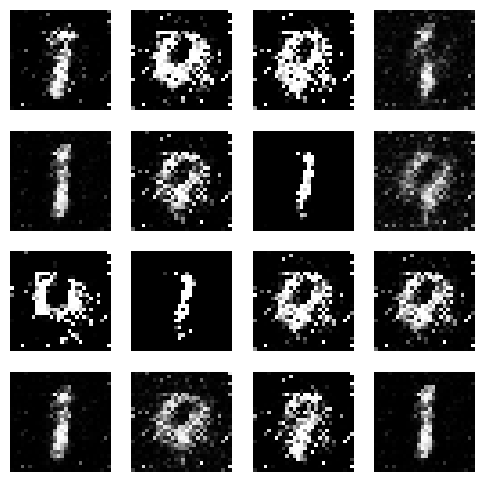

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Hyperparameters
batch_size = 64
lr = 0.0002
epochs = 20
latent_dim = 100

# Load MNIST Dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

dataloader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True
)

# Generator
class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(True),

            nn.Linear(256, 512),
            nn.ReLU(True),

            nn.Linear(512, 1024),
            nn.ReLU(True),

            nn.Linear(1024, 784),
            nn.Tanh()
        )

    def forward(self, z):
        img = self.model(z)
        return img.view(-1, 1, 28, 28)

# Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(784, 1024),
            nn.LeakyReLU(0.2),

            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        img_flat = img.view(img.size(0), -1)
        return self.model(img_flat)

# Create Models
generator = Generator()
discriminator = Discriminator()

# Loss and Optimizers
criterion = nn.BCELoss()

optimizer_G = optim.Adam(generator.parameters(), lr=lr)
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr)

# Training
for epoch in range(epochs):

    for i, (real_imgs, _) in enumerate(dataloader):

        batch_size_current = real_imgs.size(0)

        real_labels = torch.ones(batch_size_current, 1)
        fake_labels = torch.zeros(batch_size_current, 1)

        # ---------------------
        # Train Discriminator
        # ---------------------
        optimizer_D.zero_grad()

        outputs_real = discriminator(real_imgs)
        d_loss_real = criterion(outputs_real, real_labels)

        noise = torch.randn(batch_size_current, latent_dim)
        fake_imgs = generator(noise)

        outputs_fake = discriminator(fake_imgs.detach())
        d_loss_fake = criterion(outputs_fake, fake_labels)

        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        optimizer_D.step()

        # ---------------------
        # Train Generator
        # ---------------------
        optimizer_G.zero_grad()

        outputs = discriminator(fake_imgs)
        g_loss = criterion(outputs, real_labels)

        g_loss.backward()
        optimizer_G.step()

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"D Loss: {d_loss.item():.4f} "
        f"G Loss: {g_loss.item():.4f}"
    )

# Generate Images
noise = torch.randn(16, latent_dim)
generated_imgs = generator(noise).detach()

fig, axes = plt.subplots(4, 4, figsize=(6,6))

for i, ax in enumerate(axes.flat):
    ax.imshow(
        generated_imgs[i].squeeze(),
        cmap='gray'
    )
    ax.axis('off')

plt.show()

In [ ]:
pip install inference-sdk

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.3/74.3 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 71.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 MB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 102.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 7.1 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: pillow
    Found existing installation: pillow 11.3.0
    Uninstalling pillow-11.3.0:
      Successfully u

In [ ]:
from inference_sdk import InferenceHTTPClient

In [ ]:
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 77.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 111.3 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.18
    Uninstalling idna-3.18:
      Successfully uninstalled idna-3.18
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requ

In [ ]:
from roboflow import Roboflow

rf = Roboflow(api_key="2RQDHdCiliiIGON583at")

print(rf.workspace())

loading Roboflow workspace...
{
  "name": "Gangammas Workspace",
  "url": "gangammas-workspace-lceys",
  "projects": [
    "gangammas-workspace-lceys/gangamma"
  ]
}


In [ ]:
from roboflow import Roboflow

# Initialize Roboflow
rf = Roboflow(api_key="2RQDHdCiliiIGON583at")

# Load workspace
workspace = rf.workspace("gangammas-workspace-lceys")

# Load project (ONLY project name, not workspace/project path)
project = workspace.project("gangamma")

# Load model
model = project.version(1).model

# Run prediction
result = model.predict("/content/cat.png").json()

# Print result
print(result)

loading Roboflow workspace...
loading Roboflow project...
{'predictions': [{'inference_id': '3c2f950c-2763-410a-9d4c-4285a3301b2c', 'time': 0.004152180976234376, 'image': {'width': 512, 'height': 512}, 'predictions': [{'class': 'cat', 'class_id': 1, 'confidence': 0.8435}], 'top': 'cat', 'confidence': 0.8435, 'image_path': '/content/cat.png', 'prediction_type': 'ClassificationModel'}], 'image': (512, 512)}
